In [1]:
import os
os.environ['KAGGLE_USERNAME'] = 'NISHAA'
os.environ['KAGGLE_KEY'] = '6c9c7ac2c7edc579c206c0d6347dde71'

In [2]:
!pip install kaggle

In [3]:
!kaggle datasets download -d 'leftin/fruit-ripeness-unripe-ripe-and-rotten'

Dataset URL: https://www.kaggle.com/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten
License(s): CC-BY-SA-4.0
100% 3.63G/3.63G [02:03<00:00, 31.7MB/s]



In [4]:
!unzip -o fruit-ripeness-unripe-ripe-and-rotten.zip

Streaming output truncated to the last 5000 lines.
  inflating: fruit_ripeness_dataset/archive (1)/dataset/train/unripe apple/aug_0_2507.jpg  
  inflating: fruit_ripeness_dataset/archive (1)/dataset/train/unripe apple/aug_0_2511.jpg  
  inflating: fruit_ripeness_dataset/archive (1)/dataset/train/unripe apple/aug_0_2518.jpg  
  inflating: fruit_ripeness_dataset/archive (1)/dataset/train/unripe apple/aug_0_2524.jpg  
  inflating: fruit_ripeness_dataset/archive (1)/dataset/train/unripe apple/aug_0_2530.jpg  
  inflating: fruit_ripeness_dataset/archive (1)/dataset/train/unripe apple/aug_0_2537.jpg  
  inflating: fruit_ripeness_dataset/archive (1)/dataset/train/unripe apple/aug_0_2539.jpg  
  inflating: fruit_ripeness_dataset/archive (1)/dataset/train/unripe apple/aug_0_254.jpg  
  inflating: fruit_ripeness_dataset/archive (1)/dataset/train/unripe apple/aug_0_2542.jpg  
  inflating: fruit_ripeness_dataset/archive (1)/dataset/train/unripe apple/aug_0_2544.jpg  
  inflating: fruit_ripeness_da

In [5]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [6]:
train_data_dir = '/content/fruit_ripeness_dataset/archive (1)/dataset/train'
test_data_dir = '/content/fruit_ripeness_dataset/archive (1)/dataset/test'

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    seed=42
)

Found 16217 files belonging to 9 classes.


In [7]:
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_data_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)
class_names = train_dataset.class_names
print("Classes:", class_names)
print("Number of Classes:", len(class_names))

Found 3739 files belonging to 9 classes.
Classes: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges', 'unripe apple', 'unripe banana', 'unripe orange']
Number of Classes: 9


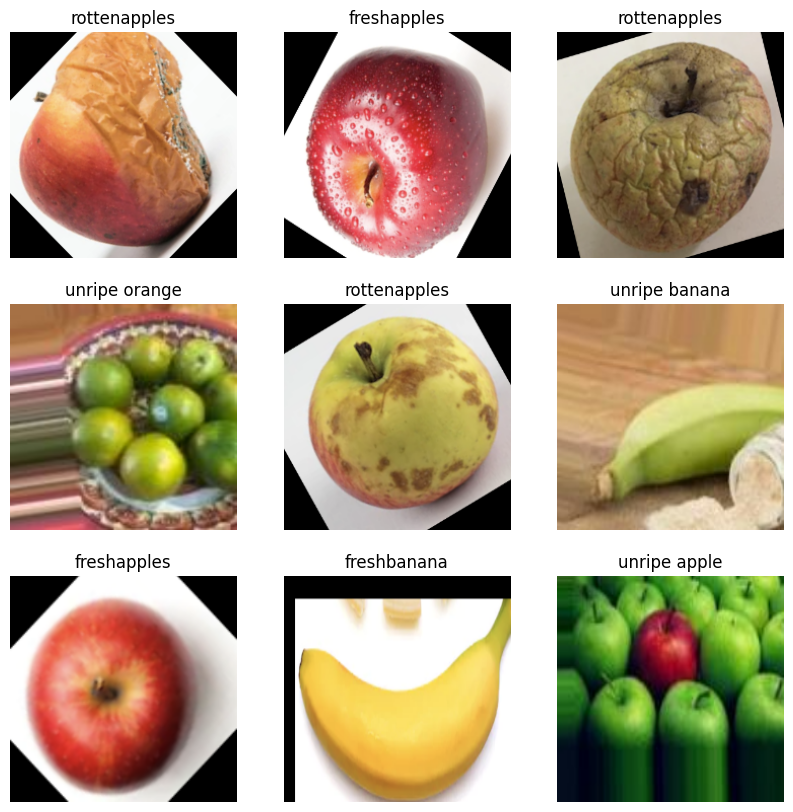

In [8]:
plt.figure(figsize=(10, 10))
class_names = train_dataset.class_names

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [9]:
import os

valid_extensions = ('.jpg', '.jpeg', '.png')

for folder in os.listdir(train_data_dir):

    folder_path = os.path.join(train_data_dir, folder)

    if os.path.isdir(folder_path):

        for file in os.listdir(folder_path):

            if not file.lower().endswith(valid_extensions):
                print("Invalid file:", file)

from PIL import Image

In [10]:
from PIL import Image
import tensorflow as tf

img_path = '/content/fruit_ripeness_dataset/archive (1)/dataset/train/freshapples/rotated_by_75_Screen Shot 2018-06-08 at 5.13.25 PM.png'

img = Image.open(img_path)
img = img.convert("RGB")

image_size = (224, 224)

normalization_layer = tf.keras.layers.Rescaling(1./255)

In [11]:
for image_batch, label_batch in train_dataset.take(1):

    print("Image Batch Shape :", image_batch.shape)
    print("Label Batch Shape :", label_batch.shape)

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)


In [12]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [13]:
for image_batch, label_batch in train_dataset.take(1):
    print("Minimum Pixel :", tf.reduce_min(image_batch).numpy())
    print("Maximum Pixel :", tf.reduce_max(image_batch).numpy())

Minimum Pixel : 0.0
Maximum Pixel : 1.0


In [14]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
])

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import Input

model = Sequential([
    Input(shape=(224,224,3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(len(class_names), activation='softmax')
])

In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,121 (42.61 MB)

 Trainable params: 11,170,121 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=15
)

Epoch 1/15
507/507 ━━━━━━━━━━━━━━━━━━━━ 61s 105ms/step - accuracy: 0.6083 - loss: 0.9874 - val_accuracy: 0.7767 - val_loss: 0.5132
Epoch 2/15
507/507 ━━━━━━━━━━━━━━━━━━━━ 49s 97ms/step - accuracy: 0.7170 - loss: 0.6652 - val_accuracy: 0.7962 - val_loss: 0.4615
Epoch 3/15
507/507 ━━━━━━━━━━━━━━━━━━━━ 45s 88ms/step - accuracy: 0.7545 - loss: 0.5682 - val_accuracy: 0.7922 - val_loss: 0.4925
Epoch 4/15
507/507 ━━━━━━━━━━━━━━━━━━━━ 46s 91ms/step - accuracy: 0.7739 - loss: 0.5211 - val_accuracy: 0.8385 - val_loss: 0.3858
Epoch 5/15
507/507 ━━━━━━━━━━━━━━━━━━━━ 45s 89ms/step - accuracy: 0.7958 - loss: 0.4695 - val_accuracy: 0.8489 - val_loss: 0.3536
Epoch 6/15
507/507 ━━━━━━━━━━━━━━━━━━━━ 46s 90ms/step - accuracy: 0.8145 - loss: 0.4265 - val_accuracy: 0.8382 - val_loss: 0.3910
Epoch 7/15
507/507 ━━━━━━━━━━━━━━━━━━━━ 84s 94ms/step - accuracy: 0.8288 - loss: 0.3935 - val_accuracy: 0.8649 - val_loss: 0.3351
Epoch 8/15
507/507 ━━━━━━━━━━━━━━━━━━━━ 47s 92ms/step - accuracy: 0.8529 - loss: 0.3453 -

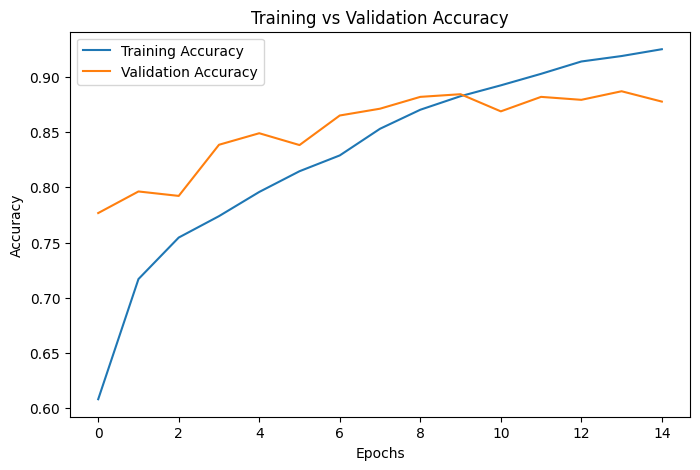

In [18]:
import matplotlib.pyplot as p
p.figure(figsize=(8,5))

p.plot(history.history['accuracy'], label='Training Accuracy')
p.plot(history.history['val_accuracy'], label='Validation Accuracy')

p.title("Training vs Validation Accuracy")
p.xlabel("Epochs")
p.ylabel("Accuracy")
p.legend()

p.show()

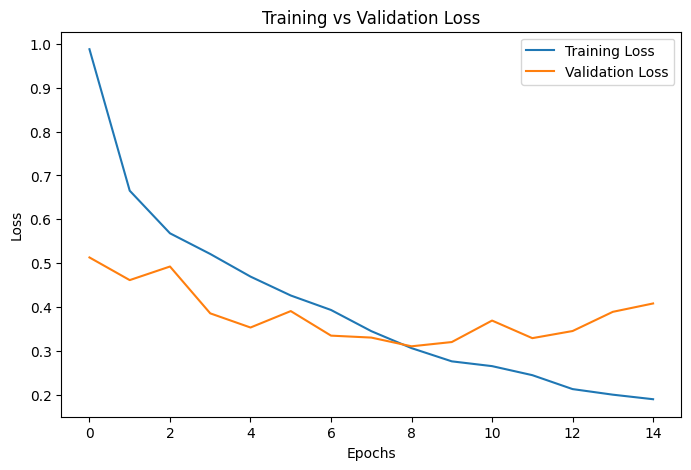

In [19]:
p.figure(figsize=(8,5))

p.plot(history.history['loss'], label='Training Loss')
p.plot(history.history['val_loss'], label='Validation Loss')

p.title("Training vs Validation Loss")
p.xlabel("Epochs")
p.ylabel("Loss")
p.legend()

p.show()

In [20]:
loss, accuracy = model.evaluate(test_dataset)

print(f"\nValidation Loss    : {loss:.4f}")
print(f"Validation Accuracy : {accuracy*100:.2f}%")

117/117 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.8775 - loss: 0.4083

Validation Loss    : 0.4083
Validation Accuracy : 87.75%


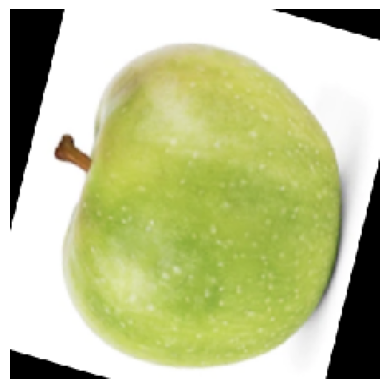

In [21]:
from tensorflow.keras.preprocessing import image

img_path = '/content/fruit_ripeness_dataset/archive (1)/dataset/train/freshapples/rotated_by_75_Screen Shot 2018-06-08 at 5.13.25 PM.png'

img = image.load_img(
    img_path,
    target_size=(224,224)
)
p.imshow(img)
p.axis("off")
p.show()

In [22]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = '/content/fruit_ripeness_dataset/archive (1)/dataset/train/freshapples/rotated_by_75_Screen Shot 2018-06-08 at 5.13.25 PM.png'
img = image.load_img(img_path, target_size=(224, 224))

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

prediction = model.predict(img_array)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[9.9998438e-01 2.6771120e-12 5.7454962e-08 1.5645101e-05 3.9129477e-24
  5.2483076e-14 3.3921987e-09 2.8400194e-16 5.2844130e-20]]


In [23]:
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = [
    'freshapples',
    'freshbanana',
    'freshoranges',
    'rottenapples',
    'rottenbanana',
    'rottenoranges',
    'unripe apple',
    'unripe banana',
    'unripe orange'
]

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index] * 100

if "fresh" in predicted_class:
    ripeness = "Ripe"
elif "rotten" in predicted_class:
    ripeness = "Rotten"
else:
    ripeness = "Unripe"

print("Fruit Class :", predicted_class)
print("Ripeness Stage :", ripeness)
print(f"Confidence : {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Fruit Class : freshapples
Ripeness Stage : Ripe
Confidence : 100.00%


In [24]:
model_save_path = "/content/fruit_ripeness_classifier_model.keras"

model.save(model_save_path)

print(f"Model saved successfully to: {model_save_path}")
print("You can now download the model from the Colab file browser (left sidebar -> Files).")

Model saved successfully to: /content/fruit_ripeness_classifier_model.keras
You can now download the model from the Colab file browser (left sidebar -> Files).
